# CHAPTER 2 - Introduction to numpy
This chapter, along with chapter 3, outlines techniques for effectively loading, storing and manipulating in-memory data in Python. For example, images–particularly digital images–can be thought of as simply two-dimensional arrays of numbers representing pixel brightness across the area. Sound clips can be thought of as one-dimensional arrays of intensity versus time. Text can be converted in various ways into numerical representations, perhaps binary digits representing the frequency of certain words or pairs of words.

This chapter will cover NumPy in detail. NumPy (short for Numerical Python) provides an efficient interface to store and operate on dense data buffers. In some ways, NumPy arrays are like Python's built-in list type, but NumPy arrays provide much more efficient storage and data operations as the arrays grow larger in size. NumPy arrays form the core of nearly the entire ecosystem of data science tools in Python, so time spent learning to use NumPy effectively will be valuable no matter what aspect of data science interests you.

You can test if you have NumPy installed by executing the following command.

In [2]:
import numpy as np
np.__version__

'2.4.4'

# 1.- Understanding Data Types in Python
Effective data-driven science and computation requires understanding how data is stored and manipulated. This section outlines and contrasts how arrays of data are handled in Python, and how NumPy improves on this. Understanding this difference is fundamental to understand much of the material throughout the rest of the book.

Users of Python are often drawn-in by its ease of use, one piece of which is dynamic typing. While a statically-typed language like C or Java requires each variable to be explicitly declared, a dynamically-typed language like Python skips this specification. For example a loop in python code would be something like:

In [4]:
result = 0
for i in range(100):
    result += i

Notice the main difference: in C, the data types of each variable are explicitly declared, while in Python the types are dynamically inferred. This means, for example, that we can assign any kind of data to any variable. For example, in the example below, we change dynamically the data type of x, in C, this would create a compiling error.

In [5]:
x = 4
x = "four"

## A Python Integer Is More Than Just an Integer
The standard Python implementation is written in C. This means that every Python object is simply a cleverly-disguised C structure, which contains not only its value, but other information as well. For example, when we define an integer in Python, such as x = 10000, x is not just a "raw" integer. It's actually a pointer to a compound C structure, which contains several values. Looking through the Python 3.4 source code, we find that the integer (long) type definition effectively looks like this (once the C macros are expanded).

```C
struct _longobject {
    long ob_refcnt;
    PyTypeObject *ob_type;
    size_t ob_size;
    long ob_digit[1];
};
```

A single integer in Python 3.4 actually contains four pieces:
* `ob_refcnt`, a reference count that helps Python silently handle memory allocation and deallocation
* `ob_type`, which encodes the type of the variable
* `ob_size`, which specifies the size of the following data members
* `ob_digit`, which contains the actual integer value that we expect the Python variable to represent.

This means that there is some overhead in storing an integer in Python as compared to an integer in a compiled language like C, as illustrated in the following figure:
https://jakevdp.github.io/PythonDataScienceHandbook/figures/cint_vs_pyint.png


Here `PyObject_HEAD` is the part of the structure containing the reference count, type code, and other pieces mentioned before.

Notice the difference here: a C integer is essentially a label for a position in memory whose bytes encode an integer value. A Python integer is a pointer to a position in memory containing all the Python object information, including the bytes that contain the integer value. This extra information in the Python integer structure is what allows Python to be coded so freely and dynamically. All this additional information in Python types comes at a cost, however, which becomes especially apparent in structures that combine many of these objects.

## A Python List Is More Than Just a List
Let's consider what happens when we use a Python data structure that holds many Python objects. The standard mutable multi-element container in Python is the list. We can create a list of integers as follows:

In [10]:
L = list(range(10))
print(L)
type(L[0])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


int

Or, similarly, a list of strings:

In [11]:
L2 = [str(c) for c in L]
print(L2)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


Since Python is dynamic typing, we can even create hetergeneous lists like in:

In [1]:
L3 = [True, "2", 3.0, 4]
[type(item) for item in L3]

[bool, str, float, int]

But this flexibility comes at a cost: to allow these flexible types, each item in the list must contain its own type info, reference count, and other information–that is, each item is a complete Python object. In the special case that all variables are of the same type, much of this information is redundant: it can be much more efficient to store data in a fixed-type array. The difference between a dynamic-type list and a fixed-type (NumPy-style) array is illustrated in the following figure:

https://jakevdp.github.io/PythonDataScienceHandbook/figures/array_vs_list.png

At the implementation level, the array essentially contains a single pointer to one contiguous block of data. The Python list, on the other hand, contains a pointer to a block of pointers, each of which in turn points to a full Python object like the Python integer we saw earlier. Again, the advantage of the list is flexibility: because each list element is a full structure containing both data and type information, the list can be filled with data of any desired type. Fixed-type NumPy-style arrays lack this flexibility, but are much more efficient for storing and manipulating data.

## Fixed Type Arrays in Python
Python offers several different options for storing data in efficient, fixed-type data buffers. The built-in `array` module (available since Python 3.3) can be used to create dense arrays of a uniform type:

In [2]:
import array
L = list(range(10))
A = array.array('i', L)
print(A)

array('i', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


Here `'i'` is a type code indicating the contents are integers.

Much more useful, however, is the `ndarray` object of the NumPy package. While Python's array object provides efficient storage of array-based data, NumPy adds to this efficient operations on that data. We will explore these operations in later sections; here we'll demonstrate several ways of creating a NumPy array.

We'll start with the standard NumPy import, under the alias `np`:

In [3]:
import numpy as np

## Creating Arrays from Python Lists
First, we can use np.array to create arrays from Python lists:

In [ ]:
np.array([1, 4, 2, 5, 3])

Remember that unlike Python lists, NumPy is constrained to arrays that all contain the same type. If types do not match, NumPy will upcast if possible (here, integers are up-cast to floating point):

In [4]:
np.array([3.14, 4, 2, 3])

array([3.14, 4.  , 2.  , 3.  ])

If we want to explicitly set the data type of the resulting array, we can use the `dtype` keyword:

In [7]:
np.array([1, 2, 3, 4], dtype='float32')

array([1., 2., 3., 4.], dtype=float32)

Finally, unlike Python lists, NumPy arrays can explicitly be multi-dimensional; here's one way of initializing a multidimensional array using a list of lists, where the inner lists are treated as rows of the resulting two-dimensional array:

In [8]:
np.array([range(i, i+3) for i in [2, 4, 6]])

array([[2, 3, 4],
       [4, 5, 6],
       [6, 7, 8]])

## Creating Arrays from the Scratch

In [21]:
# Create a length-10 integer array filled with zeros
print(np.zeros(10, dtype=int))

# Create a 3x5 floating-point array filled with ones
print(np.ones((3, 5), dtype='float32'))

# Create a 3x5 array filled with 3.14
print(np.full((3, 5), 3.14))

# Create an array filled with a linear sequence
# Starting at 0, ending at 20, stepping by 2
# (this is similar to the built-in range() function)
print(np.arange(0, 20, 2))

# Create an array of five values evenly spaced between 0 and 1
print(np.linspace(0, 1, 5))

# Create a 3x3 array of uniformly distributed
# random values between 0 and 1
print(np.random.random((3, 3)))


# Create a 3x3 array of normally distributed random values
# with mean 0 and standard deviation 1
print(np.random.normal(0, 1, (3, 3)))

# Create a 3x3 array of random integers in the interval [0, 10)
print(np.random.randint(0, 10, (3,3)))


# Create a 3x3 identity matrix
print(np.eye(3,3))

# Create an uninitialized array of three integers
# The values will be whatever happens to already exist at that memory location
np.empty(3)

[0 0 0 0 0 0 0 0 0 0]
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
[[3.14 3.14 3.14 3.14 3.14]
 [3.14 3.14 3.14 3.14 3.14]
 [3.14 3.14 3.14 3.14 3.14]]
[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]
[[0.29657892 0.24020675 0.12439848]
 [0.16288661 0.44023511 0.9440479 ]
 [0.95728876 0.90556085 0.91232304]]
[[ 0.25147884 -0.17048444  1.07676204]
 [-1.31526532 -1.42030083 -1.51776532]
 [-1.56864354 -1.17337948 -1.30661876]]
[[5 3 1]
 [9 7 6]
 [8 3 1]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


array([1., 1., 1.])

## NumPy Standard Data Types
NumPy arrays contain values of a single type, so it is important to have detailed knowledge of those types and their limitations. Because NumPy is built in C, the types will be familiar to users of C, Fortran, and other related languages.

The standard NumPy data types are listed in the following table. Note that when constructing an array, they can be specified using a string:

In [22]:
np.zeros(10, dtype='int16')

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int16)

**Data** **type**	**Description**

`bool_`	Boolean (True or False) stored as a byte

`int_`	Default integer type (same as C long; normally either int64 or int32)

`intc`	Identical to C int (normally int32 or int64)

`intp`	Integer used for indexing (same as C ssize_t; normally either int32 or int64)

`int8`	Byte (-128 to 127)

`int16`	Integer (-32768 to 32767)

`int32`	Integer (-2147483648 to 2147483647)

`int64`	Integer (-9223372036854775808 to 9223372036854775807)

`uint8`	Unsigned integer (0 to 255)

`uint16`	Unsigned integer (0 to 65535)

`uint32`	Unsigned integer (0 to 4294967295)

`uint64`	Unsigned integer (0 to 18446744073709551615)

`float_`	Shorthand for float64.

`float16`	Half precision float: sign bit, 5 bits exponent, 10 bits mantissa

`float32`	Single precision float: sign bit, 8 bits exponent, 23 bits mantissa

`float64`	Double precision float: sign bit, 11 bits exponent, 52 bits mantissa

`complex_`	Shorthand for complex128.

`complex64`	Complex number, represented by two 32-bit floats

`complex128`	Complex number, represented by two 64-bit floats

More advanced type specification is possible, such as specifying big or little endian numbers; for more information, refer to the NumPy documentation. NumPy also supports compound data types, which will be covered in Structured Data: NumPy's Structured Arrays.

# 2.- The Basics of NumPy Arrays

Data manipulation in Python is nealy synonymous with NumPy array manipulation, even newer tools like Pandas are built around the NumPy array. This section shows how to split, reshape, join the arrays and some operation types, altogether comprise the building blocks of many other examples used throughout the book.

We'll cover a few categories of basic array manipulations here:
* Attributes of arrays: Determing the size, shape, memory consumption, and data types of arrays.

* Indexing of arrays: Getting and setting the value of individual array elements.

* Slicing of arrays: Getting and setting smaller subarrays within a larger array.

* Reshaping of arrays: Changing the shape of a given array.

* Joining and splitting of arrays: Combining multiple arrays into one, and splitting one array into many.

## NumPy Array Attributes
We'll start by defining three random arrays, a one-dimensional, two-dimensional, and three-dimensional array. We'll use NumPy's random number generator, which we will seed with a set value in order to ensure that the same random arrays are generated each time this code is run:

In [4]:
import numpy as np

np.random.seed(0) # seed for reproducibility

x1 = np.random.randint(10, size=6) # One-dimensional array
print(x1)
x2 = np.random.randint(10, size=(3, 4))  # Two-dimensional array
print(x2)
x3 = np.random.randint(10, size=(3, 4, 5))  # Three-dimensional array
print(x3)

print("x3 ndim: ", x3.ndim)
print("x3 shape:", x3.shape)
print("x3 size: ", x3.size)


print("dtype:", x3.dtype)



[5 0 3 3 7 9]
[[3 5 2 4]
 [7 6 8 8]
 [1 6 7 7]]
[[[8 1 5 9 8]
  [9 4 3 0 3]
  [5 0 2 3 8]
  [1 3 3 3 7]]

 [[0 1 9 9 0]
  [4 7 3 2 7]
  [2 0 0 4 5]
  [5 6 8 4 1]]

 [[4 9 8 1 1]
  [7 9 9 3 6]
  [7 2 0 3 5]
  [9 4 4 6 4]]]
x3 ndim:  3
x3 shape: (3, 4, 5)
x3 size:  60
dtype: int64


Other attributes include `itemsize`, which lists the size (in bytes) of each array element, and `nbytes`, which lists the total size (in bytes) of the array:

In [5]:
print("itemsize:", x3.itemsize, "bytes")
print("nbytes:", x3.nbytes, "bytes")

itemsize: 8 bytes
nbytes: 480 bytes


## Array Indexing: Accesing Single Elements

If you are familiar wiht python's standard list indexign, indexing in NumPy will feel quite familiar. In a one-dimensional array, the i-th value counting from zero cna be accesses by specifying the desired index in square brackets:

In [6]:
x1

array([5, 0, 3, 3, 7, 9])

In [7]:
x1[0]

np.int64(5)

In [8]:
x1[4]

np.int64(7)

To index from the end of the array, you can use negative indeces:

In [9]:
x1[-1]

np.int64(9)

In [10]:
x1[-2]

np.int64(7)

In a multi-dimensional array, items can be accessed using a comma-separeted tuple of indeces:

In [11]:
x2

array([[3, 5, 2, 4],
       [7, 6, 8, 8],
       [1, 6, 7, 7]])

In [12]:
x2[0,0]

np.int64(3)

In [14]:
x2[2,0]

np.int64(1)

In [15]:
x2[2,-1]

np.int64(7)

Using this indexing system you can also modify single values:

In [16]:
x2[0,0] = 12
x2

array([[12,  5,  2,  4],
       [ 7,  6,  8,  8],
       [ 1,  6,  7,  7]])

It is important to keep in mind that NumPy arrays have a fixed type. This means that if you try to add a floating-point vlaue to an integer array, its value will be truncated:

In [17]:
x1[0] = 3.14159
x1

array([3, 0, 3, 3, 7, 9])

## Array slicing: Accesing Subarrays
Just we can use square brackets to access individual array elements, we can also use them to access subarrays with the slice notation, marked by the colon (:) character. The NumPy slicing syntax follows that of the standard Python list, you can do it as follows:

``` 
x[start: stop: step]
```

If any of these are unspecified, they default values are `start-0`, `stop=size of dimension`, `step = 1`. We'll take a look at accessing sub-arrays in one and multiple dimentions

### One-dimensional subarrays

In [ ]:
x = np.arange(10)
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [22]:
x[:5]

array([0, 1, 2, 3, 4])

In [21]:
x[5:]

array([5, 6, 7, 8, 9])

In [23]:
x[4:7]

array([4, 5, 6])

In [24]:
x[::2]

array([0, 2, 4, 6, 8])

In [25]:
x[1::2]

array([1, 3, 5, 7, 9])

A potentially confusing case is when the `step` value is negative. In this case, the defaults for `start` and `stop` are swapped. This becomes a convenient way to reverse an array:

In [26]:
x[::-1]

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [27]:
x[5::-2]

array([5, 3, 1])

### Multi-dimensional subarrays
Multi-dimensional slices work in the same way, with multiples slices separated by commas. For example:

In [29]:
x2

array([[12,  5,  2,  4],
       [ 7,  6,  8,  8],
       [ 1,  6,  7,  7]])

In [30]:
x2[:2, :3]

array([[12,  5,  2],
       [ 7,  6,  8]])

In [31]:
x2[:3, ::2]

array([[12,  2],
       [ 7,  8],
       [ 1,  7]])

Finally, subarray dimensions can even be reversed together

In [32]:
x2[::-1, ::-1]

array([[ 7,  7,  6,  1],
       [ 8,  8,  6,  7],
       [ 4,  2,  5, 12]])

#### Accessing rows and columns
One commonly needed routine is accessing of single rows or columns of an array. This can be done by combining indexing and slicing, using an empty slice marked by a single colon (`:`):

In [33]:
print(x2[:,0])

[12  7  1]


In [35]:
print(x2[0,:])
print(x2[0])  # equivalent to x2[0, :]



[12  5  2  4]
[12  5  2  4]


### Subarrays as no-copy views
One important-and extremely useful-thing to know about array slices is that they return views rather than copies of the data. This is one area in which NumPy array slicing differs from Python list slicing: in lists, slices will be copies. Consider our two-dimensional array from before:

In [36]:
print(x2)

[[12  5  2  4]
 [ 7  6  8  8]
 [ 1  6  7  7]]


Let's extract a `2 x 2` subarray from this:

In [37]:
x2_sub = x2[:2, :2]
print(x2_sub)

[[12  5]
 [ 7  6]]


Now, if we modify this subarray, we'll see that the original array is changed!

In [40]:
x2_sub[0, 0] = 99
print(x2_sub)
print(x2)

[[99  5]
 [ 7  6]]
[[99  5  2  4]
 [ 7  6  8  8]
 [ 1  6  7  7]]


This default behavior is actually quite useful: it means that when we work with large datasets, we can accesss and process pieces of these datasets without the need of copy the underlying data buffer.

### Creating copies of arrays
Despite the nice features of array views, it is sometimes useful to instead explicitly copy the data within an array or a subarray. This can be most easily done with the `copy()` method:

In [41]:
x2_sub_copy = x2[:2, :2].copy()
print(x2_sub_copy)

[[99  5]
 [ 7  6]]


If we now modify this subarray, the original array is not touched:

In [42]:
x2_sub_copy[0, 0] = 42
print(x2_sub_copy)

print(x2)

[[42  5]
 [ 7  6]]
[[99  5  2  4]
 [ 7  6  8  8]
 [ 1  6  7  7]]


## Reshaping of Arrays
Another usefull type of operation becauuse it gives flexibility with the `reshape` method. For example, if you want to put the numbers 1 through 9 in a 3 x 3 grid you can do the following:

In [3]:
import numpy as np
grid = np.arange(1, 10).reshape((3,3))
print(grid)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


Note that for this to work, the size of the initial array must match the size of the reshaped array. Where possible, the reshape method will use a no-copy view of the initial array, but with non-contiguous memory buffers this is not always the case.

Another common reshaping pattern is the conversion of a one-dimensional array into a two-dimensional row or column matrix. This can be done with the reshape method, or more easily done by making use of the `newaxis` keyword within a slice operation:

In [4]:
x = np.array([1, 2, 3])

# row vector via reshape
x.reshape((1,3))

array([[1, 2, 3]])

In [6]:
x[np.newaxis, :]

array([[1, 2, 3]])

In [7]:
x.reshape((3,1))

array([[1],
       [2],
       [3]])

In [8]:
x[:, np.newaxis]

array([[1],
       [2],
       [3]])

## Array Concatenation and Splitting
All of the preceding routines worked on single arryas. It's also possible to combine arrays into one, and to conversely split a single array into multiple arrays. We'll take a look at those operations here.

### Concatenation of arrays
Concatenation, or joining of two arrays in NumPy, is primarly accomplish through `np.concatenate`, `np.vstack` and `np.hstack`. `np.concatenate` takes a touple or list of arrays as its first argument, as we can see here:

In [9]:
x = np.array([1, 2, 3])
y = np.array([3, 2, 1])
np.concatenate([x, y])

array([1, 2, 3, 3, 2, 1])

You can also concatenate more than two arrays at once:

In [10]:
z = [99, 99, 99]
print(np.concatenate([x, y, z]))

[ 1  2  3  3  2  1 99 99 99]


It can be also used for two-dimensional arrays:

In [11]:
grid = np.array([[1, 2, 3], [4, 5, 6]])

In [12]:
np.concatenate([grid, grid])

array([[1, 2, 3],
       [4, 5, 6],
       [1, 2, 3],
       [4, 5, 6]])

In [14]:
# concatenate along the second axis (zero-indexed)
np.concatenate([grid, grid], axis=1)

array([[1, 2, 3, 1, 2, 3],
       [4, 5, 6, 4, 5, 6]])

For working with arrays of mixed dimensions, it can be clearer to use the `np.vstack` (vertical stack) and `np.hstack` (horizontal stack) functions:

In [15]:
x = np.array([1, 2, 3])
grid = np.array([[9,8,7], [6, 5, 3]])

np.vstack([x, grid])

array([[1, 2, 3],
       [9, 8, 7],
       [6, 5, 3]])

In [16]:
# horizontally stack the arrays
y = np.array([[99],
              [99]])
np.hstack([grid, y])

array([[ 9,  8,  7, 99],
       [ 6,  5,  3, 99]])

Similary, `np.dstack`` will stack arrays along the third axis.

### Splitting of arrays
The opposite of concatenation is splitting, which is cimplemented by the functions `np.split`, `np.hsplit`, and `np.vsplit`. For each of these, we can pass a list of indices giving the split points:

In [19]:
x = [1, 2, 3, 99, 99, 3, 2, 1]
x1, x2, x3 = np.split(x, [3, 5])
print(x1, x2, x3)

[1 2 3] [99 99] [3 2 1]


Notice that N split-points, leads to N+1 subarrays. The related functions `np.hsplit` and `np.vsplit` are similar:

In [20]:
grid = np.arange(16).reshape((4, 4))
grid

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [21]:
upper, lower = np.vsplit(grid, [2])
print(upper)
print(lower)

[[0 1 2 3]
 [4 5 6 7]]
[[ 8  9 10 11]
 [12 13 14 15]]


In [22]:
left, right = np.hsplit(grid, [2])
print(left)
print(right)

[[ 0  1]
 [ 4  5]
 [ 8  9]
 [12 13]]
[[ 2  3]
 [ 6  7]
 [10 11]
 [14 15]]


# 3.- Computation on NumPy Arrays: Universal Functions
Up until now, we have been discussing some of the basic nuts and bolts of NumPy; in the next few sections, we will dive into the reasons that NumPy is so important in the Python data science world. Namely, it provides an easy and flexible interface to optimized computation with arrays of data.

Computation on NumPy arrays can be very fast, or it can be very slow. The key to making it fast is to use vectorized operations, generally implemented through NumPy's universal functions (ufuncs). This section motivates the need for NumPy's ufuncs, which can be used to make repeated calculations on array elements much more efficient. It then introduces many of the most common and useful arithmetic ufuncs available in the NumPy package.

## The slowness of loops
Python's default implementation (known as CPython) does some operations very slowly. This is in part due to the dynamic, interpreted nature of the language: the fact that types are flexible, so that sequences of operations cannot be compiled down to efficient machine code as in languages like C and Fortran. Recently there have been various attempts to address this weakness: well-known examples are the PyPy project, a just-in-time compiled implementation of Python; the Cython project, which converts Python code to compilable C code; and the Numba project, which converts snippets of Python code to fast LLVM bytecode. Each of these has its strengths and weaknesses, but it is safe to say that none of the three approaches has yet surpassed the reach and popularity of the standard CPython engine.

The relative sluggishness of Python generally manifests itself in situations where many small operations are being repeated – for instance looping over arrays to operate on each element. For example, imagine we have an array of values and we'd like to compute the reciprocal of each. A straightforward approach might look like this:

In [24]:
import numpy as np
np.random.seed(0)

def compute_reciprocals(values):
    output = np.empty(len(values))
    for i in range(len(values)):
        output[i] = 1.0 / values[i]
    return output

values = np.random.randint(1, 10, size=5)
compute_reciprocals(values)

array([0.16666667, 1.        , 0.25      , 0.25      , 0.125     ])

This implementation probably feels fairly natural to someone from, say, a C or Java background. But if we measure the execution time of this code for a large input, we see that this operation is very slow, perhaps surprisingly so! We'll benchmark this with IPython's %timeit magic (discussed in Profiling and Timing Code):

In [25]:
big_array = np.random.randint(1, 100, size=1000000)
%timeit compute_reciprocals(big_array)

585 ms ± 2.23 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


It takes several seconds to compute these million operations and to store the result! When even cell phones have processing speeds measured in Giga-FLOPS (i.e., billions of numerical operations per second), this seems almost absurdly slow. It turns out that the bottleneck here is not the operations themselves, but the type-checking and function dispatches that CPython must do at each cycle of the loop. Each time the reciprocal is computed, Python first examines the object's type and does a dynamic lookup of the correct function to use for that type. If we were working in compiled code instead, this type specification would be known before the code executes and the result could be computed much more efficiently.

## Introducing UFuncs
For many types of operations, NumPy provides a convenient interface into just this kind of statically typed, compiled routine. This is known as a vectorized operation. This can be accomplished by simply performing an operation on the array, which will then be applied to each element. This vectorized approach is designed to push the loop into the compiled layer that underlies NumPy, leading to much faster execution.

Compare the results of the following two:

In [26]:
print(compute_reciprocals(values))
print(1.0 / values)

[0.16666667 1.         0.25       0.25       0.125     ]
[0.16666667 1.         0.25       0.25       0.125     ]


Looking at the execution time for our big array, we see that it completes orders of magnitude faster than the Python loop:

In [27]:
%timeit (1.0 / big_array)

605 μs ± 4.16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Vectorized operations in NumPy are implemented via ufuncs, whose main purpose is to quickly execute repeated operations on values in NumPy arrays. Ufuncs are extremely flexible – before we saw an operation between a scalar and an array, but we can also operate between two arrays:

In [28]:
np.arange(5) / np.arange(1, 6)

array([0.        , 0.5       , 0.66666667, 0.75      , 0.8       ])

And ufunc operations are not limited to one-dimensional arrays–they can also act on multi-dimensional arrays as well:

In [29]:
x = np.arange(9).reshape((3, 3))
2 ** x

array([[  1,   2,   4],
       [  8,  16,  32],
       [ 64, 128, 256]])

Computations using vectorization through ufuncs are nearly always more efficient than their counterpart implemented using Python loops, especially as the arrays grow in size. Any time you see such a loop in a Python script, you should consider whether it can be replaced with a vectorized expression.

## Exploring NumPy's UFuncs
Ufuncs exist in two flavors: unary ufuncs, which operate on a single input, and binary ufuncs, which operate on two inputs. We'll see  examples of both these types of functions here.

### Array arithmetic
NumPy's ufuncs feel very natural to use because they make use of Python's native arithmetic operators. The standard addition, subtraction, multiplication, and division can all be used:

In [3]:
import numpy as np
x = np.arange(4)
print("x     =", x)
print("x + 5 =", x + 5)
print("x - 5 =", x - 5)
print("x * 2 =", x * 2)
print("x / 2 =", x / 2)
print("x // 2 =", x // 2)  # floor division

x     = [0 1 2 3]
x + 5 = [5 6 7 8]
x - 5 = [-5 -4 -3 -2]
x * 2 = [0 2 4 6]
x / 2 = [0.  0.5 1.  1.5]
x // 2 = [0 0 1 1]


There is also a unary ufunc for negation, and a `**` operator for exponentiation, and a `%` operator for modulus:

In [4]:
print("-x     = ", -x)
print("x ** 2 = ", x ** 2)
print("x % 2  = ", x % 2)

-x     =  [ 0 -1 -2 -3]
x ** 2 =  [0 1 4 9]
x % 2  =  [0 1 0 1]


In addition, these can be strung together however you wish, and the standard order of operations is respected:

In [5]:
-(0.5*x + 1) ** 2

array([-1.  , -2.25, -4.  , -6.25])

Each of these arithmetic operations are simply convenient wrappers around specific functions built into NumPy; for example, the `+` operator is a wrapper for the `add` function:

In [6]:
np.add(x, 2)

array([2, 3, 4, 5])

The following talbe is a list of the arithmetic operators implemented in NumPy and its function equivalent.

**Operator 	Equivalent ufunc 	Description**

`+` 	`np.add` 	Addition (e.g., 1 + 1 = 2)

`-` 	`np.subtract` 	Subtraction (e.g., 3 - 2 = 1)

`-` 	`np.negative` 	Unary negation (e.g., -2)

`*` 	`np.multiply` 	Multiplication (e.g., 2 * 3 = 6)

`/` 	`np.divide` 	Division (e.g., 3 / 2 = 1.5)

`//` 	`np.floor_divide` 	Floor division (e.g., 3 // 2 = 1)

`**` 	`np.power` 	Exponentiation (e.g., 2 ** 3 = 8)

`%` 	`np.mod` 	Modulus/remainder (e.g., 9 % 4 = 1)

### Absolute value
Just as NumPy understands Python's built-in arithmetic operators, it also understands Python's built-in in absolute value function

In [7]:
x = np.array([-2, -1, 0, 1, 2])
abs(x)

array([2, 1, 0, 1, 2])

The corresponding NumPy ufunc is `np.absolute`, which is also available under the alias of `np.abs`:

In [8]:
np.absolute(x)

array([2, 1, 0, 1, 2])

In [9]:
np.abs(x)

array([2, 1, 0, 1, 2])

This ufunc can also handle comples data, in which the absolute value returns the magnitude:

In [10]:
x = np.array([3 - 4j, 4 - 3j, 2 + 0j, 0 + 1j])
np.abs(x)

array([5., 5., 2., 1.])

### Trigonometric functions
NumPy provides a large number of useful ufuncs, and some of the most useful for the data scientist are the trigonometric functions. We'll start by defining an array of angles:

In [11]:
theta = np.linspace(0, np.pi, 3)

now we can compute some trigonometric functions of these values:

In [12]:
print("theta      = ", theta)
print("sin(theta) = ", np.sin(theta))
print("cos(theta) = ", np.cos(theta))
print("tan(theta) = ", np.tan(theta))

theta      =  [0.         1.57079633 3.14159265]
sin(theta) =  [0.0000000e+00 1.0000000e+00 1.2246468e-16]
cos(theta) =  [ 1.000000e+00  6.123234e-17 -1.000000e+00]
tan(theta) =  [ 0.00000000e+00  1.63312394e+16 -1.22464680e-16]


The values are computed to within machine precision, which is why values that should be zero do not always hit exactly zero. Inverse trigonometric functions are also available:

In [13]:
x = [-1, 0, 1]
print("x         = ", x)
print("arcsin(x) = ", np.arcsin(x))
print("arccos(x) = ", np.arccos(x))
print("arctan(x) = ", np.arctan(x))

x         =  [-1, 0, 1]
arcsin(x) =  [-1.57079633  0.          1.57079633]
arccos(x) =  [3.14159265 1.57079633 0.        ]
arctan(x) =  [-0.78539816  0.          0.78539816]


### Exponents and logarithms
Another common type of operation available in a NumPy ufunc are the exponentials:

In [14]:
x = [1, 2, 3]
print("x     =", x)
print("e^x   =", np.exp(x))
print("2^x   =", np.exp2(x))
print("3^x   =", np.power(3, x))

x     = [1, 2, 3]
e^x   = [ 2.71828183  7.3890561  20.08553692]
2^x   = [2. 4. 8.]
3^x   = [ 3  9 27]


The inverse of the exponentials, the logarithms, are also available. The basic `np.log` gives the natural logarithm; if you prefer to compute the base-2 logarithm or the base-10 logarithm, these are available as well:

In [15]:
x = [1, 2, 4, 10]
print("x        =", x)
print("ln(x)    =", np.log(x))
print("log2(x)  =", np.log2(x))
print("log10(x) =", np.log10(x))

x        = [1, 2, 4, 10]
ln(x)    = [0.         0.69314718 1.38629436 2.30258509]
log2(x)  = [0.         1.         2.         3.32192809]
log10(x) = [0.         0.30103    0.60205999 1.        ]


There are also some specialized versions that are useful for maintaining precision with very small input:

In [16]:
x = [0, 0.001, 0.01, 0.1]
print("exp(x) - 1 =", np.expm1(x))
print("log(1 + x) =", np.log1p(x))

exp(x) - 1 = [0.         0.0010005  0.01005017 0.10517092]
log(1 + x) = [0.         0.0009995  0.00995033 0.09531018]


When `x` is very small, these functions give more precise values than if the raw `np.log` or `np.exp` were to be used.


### Specialized ufuncs
NumPy has many more ufuncs available, including hyperbolic trig functions, bitwise arithmetic, comparison operators, conversions from radians to degrees, rounding and remainders, and much more. A look through the NumPy documentation reveals a lot of interesting functionality.

Another excellent source for more specialized and obscure ufuncs is the submodule `scipy.special`. If you want to compute some obscure mathematical function on your data, chances are it is implemented in `scipy.special`. There are far too many functions to list them all, but the following snippet shows a couple that might come up in a statistics context:

In [17]:
from scipy import special

In [18]:
# Gamma functions (generalized factorials) and related functions
x = [1, 5, 10]
print("gamma(x)     =", special.gamma(x))
print("ln|gamma(x)| =", special.gammaln(x))
print("beta(x, 2)   =", special.beta(x, 2))

gamma(x)     = [1.0000e+00 2.4000e+01 3.6288e+05]
ln|gamma(x)| = [ 0.          3.17805383 12.80182748]
beta(x, 2)   = [0.5        0.03333333 0.00909091]


In [20]:
# Error function (integral of Gaussion) its complement, and its inverse
x = np.array([0, 0.3, 0.7, 1.0])
print("erf(x)  =", special.erf(x))
print("erfc(x) =", special.erfc(x))
print("erfinv(x) =", special.erfinv(x))

erf(x)  = [0.         0.32862676 0.67780119 0.84270079]
erfc(x) = [1.         0.67137324 0.32219881 0.15729921]
erfinv(x) = [0.         0.27246271 0.73286908        inf]


## Advanced Ufunc Features
Many NumPy users make use of ufuncs wihtout ever learning their full set of features. We'll outline a few specialized features of ufuncs here.

### Specifying output
For large calculations, it is sometimes useful to be able to specify the array where the result of the calculation will be stored. Rather than creating a temporary array, this can be used to write computation results directly to the memory location where you'd like them to be. For all ufuncs, this can be done using the `out` argument of the function:

In [21]:
x = np.arange(5)
y = np.empty(5)
np.multiply(x, 10, out=y)
print(y)

[ 0. 10. 20. 30. 40.]


This can even be used with array views. For example, we can write the results of a computation to every other element of a specified array:

In [22]:
y = np.zeros(10)
np.power(2, x, out=y[::2])
print(y)

[ 1.  0.  2.  0.  4.  0.  8.  0. 16.  0.]


If we had instead written `y[::2] = 2 ** x`, this would have resulted in the creation of a temporary array to hold the results of `2 ** x`, followed by a second operation copying those values into the y array. This doesn't make much of a difference for such a small computation, but for very large arrays the memory savings from careful use of the `out` argument can be significant.

### Aggregates
For binary ufuncs, there are some interesting aggregates that can be computed directly from the object. For example, if we'd like to reduce and array with a particular operation, we can use the `reduce` method of any ufunc. A reduce repeatedly applies a given operation to the elements of an array until only a single result remains.

For example, calling `reduce` on the `add` ufunc returns the sum of all elements in the array.

In [23]:
x = np.arange(1, 6)
np.add.reduce(x)

np.int64(15)

Similarly, calling `reduce` on the `multiplay ufunc results in the product of all array elements:

In [24]:
np.multiply.reduce(x)

np.int64(120)

if we'd like to store all the intermediate results of the computation, we can instead use `accumulate`:

In [25]:
np.add.accumulate(x)

array([ 1,  3,  6, 10, 15])

In [27]:
np.multiply.accumulate(x)


array([  1,   2,   6,  24, 120])

### Outer products
Finally, any ufunc can compute the output of all pairs of two different inputs using the `outer` method. This allows you, in one line, to do things like create a multiplication table:

In [29]:
x = np.arange(1, 10)
np.multiply.outer(x, x)

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9],
       [ 2,  4,  6,  8, 10, 12, 14, 16, 18],
       [ 3,  6,  9, 12, 15, 18, 21, 24, 27],
       [ 4,  8, 12, 16, 20, 24, 28, 32, 36],
       [ 5, 10, 15, 20, 25, 30, 35, 40, 45],
       [ 6, 12, 18, 24, 30, 36, 42, 48, 54],
       [ 7, 14, 21, 28, 35, 42, 49, 56, 63],
       [ 8, 16, 24, 32, 40, 48, 56, 64, 72],
       [ 9, 18, 27, 36, 45, 54, 63, 72, 81]])

# 4.- Aggregations: Min, Max, and Everything In Between
Often when faced with a large amount of data, a first step is to compute summary statistics for the data in question. Perhaps the most common summary statistics are the mean and standard deviation, which allow you to summarize the "typical" values in a dataset, but other aggregates are useful as well (the sum, product, median, minimum and maximum, quantiles, etc.).

NumPy has fast built-in aggregation functions for working on arrays; we'll discuss and demonstrate some of them here.

## Summing the Values in an Array
As a quick example, consider computing the sum of all values in an array. Python itself can do this using the built-in `sum` function:

In [30]:
import numpy as np

In [31]:
L = np.random.random(100)
sum(L)

np.float64(46.90355604304604)

The syntax is quite similar to that of NumPy's `sum` function, and the result is the same in the simplest case:

In [32]:
np.sum(L)

np.float64(46.90355604304606)

However, because it executes the operation in compiled code, NumPy's version of the operation is computed much more quickly:

In [34]:
big_array = np.random.rand(10000000)
%timeit sum(big_array)
%timeit np.sum(big_array)

310 ms ± 1.44 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.82 ms ± 45.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Be careful, though: the `sum` function and the `np.sum` function are not identical, which can sometimes lead to confusion! In particular, their optional arguments have different meanings, and `np.sum` is aware of multiple array dimensions, as we will see in the following section.

## Minimum and Maximum
Similarly, Python has built-in `min` and `max` functions, used to find the minimum value and maximum value of any given array:

In [35]:
min(big_array), max(big_array)

(np.float64(3.828928701876677e-07), np.float64(0.9999999225453514))

NumPy's corresponding functions have similar syntax, and again operatore much more quickly

In [36]:
np.min(big_array), np.max(big_array)

(np.float64(3.828928701876677e-07), np.float64(0.9999999225453514))

In [37]:
%timeit min(big_array)
%timeit np.min(big_array)

201 ms ± 1.26 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.6 ms ± 65.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Multi dimensional aggregates
One common type of aggregation operation is an aggregate along a row or column. Say you have some data stored in two-dimensional array:


In [1]:
import numpy as np

M = np.random.random((3,4))
print(M)

[[0.13082605 0.35520739 0.56430344 0.80038569]
 [0.13745568 0.42231109 0.68468243 0.73177483]
 [0.58342013 0.55711642 0.05865044 0.22070016]]


By default, each NumPy aggregation function will return the aggregate over the entire array:

In [2]:
M.sum()

np.float64(5.24683375325787)

Aggregation functions take an additional argument specifying the axis along which the aggregate is computed. For example, we can find the minimum value within each column by specifying `axis=0`:

In [3]:
M.min(axis=0)

array([0.13082605, 0.35520739, 0.05865044, 0.22070016])

The function returns four values, corresponding to the four columns of numbers.

Similarly, we can find the maximum value within each row:

In [4]:
M.max(axis=1)

array([0.80038569, 0.73177483, 0.58342013])

The way the `axis` is specified here can be confusing to users coming from other languages. The axis keyword specifies the dimension of the array that will be collapsed, rather than the dimension that will be returned. So specifying `axis=0` means that the first axis will be collapsed: for two-dimensional arrays, this means that values within each column will be aggregated.

### Other aggregation functions
NumPy provides many other aggregation functions, but we won't discuss them in detail here. Additionally, most aggregates have a `NaN`-safe counterpart that computes the result while ignoring missing values, which are marked by the special IEEE floating-point `NaN` value. Some of these `NaN`-safe functions were not added until NumPy 1.8, so they will not be available in older NumPy versions.

The following table provides a list of useful aggregation functions available in NumPy:

**Function Name** 	**NaN-safe Version** 	**Description**

`np.sum` 	`np.nansum` 	Compute sum of elements

`np.prod` 	`np.nanprod` 	Compute product of elements

`np.mean` 	`np.nanmean` 	Compute mean of elements

`np.std` 	`np.nanstd` 	Compute standard deviation

`np.var` 	`np.nanvar` 	Compute variance

`np.min` 	`np.nanmin` 	Find minimum value

`np.max` 	`np.nanmax` 	Find maximum value

`np.argmin` 	`np.nanargmin` 	Find index of minimum value

`np.argmax` 	`np.nanargmax` 	Find index of maximum value

`np.median` 	`np.nanmedian` 	Compute median of elements

`np.percentile` 	`np.nanpercentile` 	Compute rank-based statistics of elements

`np.any` 	`N/A` 	Evaluate whether any elements are true

`np.all` 	`N/A` 	Evaluate whether all elements are true

## Example: What is the average Height of US Presidents?
Aggregates available in NumPy can be extremely useful for summarizing a set of values. As a simple example, let's consider the heights of all US presidents. The data is available on `data_v1` folder:

In [5]:
!head -4 data_v1/president_heights.csv

order,name,height(cm)
1,George Washington,189
2,John Adams,170
3,Thomas Jefferson,189


We'll use the Pandas package, which we'll explore more fully in Chapter 3, to read the file and extract this information.

In [6]:
import pandas as pd

data = pd.read_csv('data_v1/president_heights.csv')
heights = np.array(data['height(cm)'])
print(heights)

[189 170 189 163 183 171 185 168 173 183 173 173 175 178 183 193 178 173
 174 183 183 168 170 178 182 180 183 178 182 188 175 179 183 193 182 183
 177 185 188 188 182 185]


Now that we have this data array, we can compute the variety of summary statistics:

In [7]:
print("Mean height:         ", heights.mean())
print("Standard deviation:  ", heights.std())
print("Minimum height:      ", heights.min())
print("Maximum height:      ", heights.max())

Mean height:          179.73809523809524
Standard deviation:   6.931843442745892
Minimum height:       163
Maximum height:       193


Note that in each case, the aggregation operation reduced the entire array to a single summarizing value, which gives us information about the distribution of values. We may also wish to compute quantiles:

In [9]:
print("25th percentile:     ", np.percentile(heights, 25))
print("Median:          ", np.median(heights))
print("75th percentile:     ", np.percentile(heights, 75))

25th percentile:      174.25
Median:           182.0
75th percentile:      183.0


We see that the median height of US presidents is 182 cm, or just shy of six feet.

Of course, sometimes it is more useful to see a visual representation of this data, which we can accomplish using tools in Matplotlib. For example creating a the following chart:

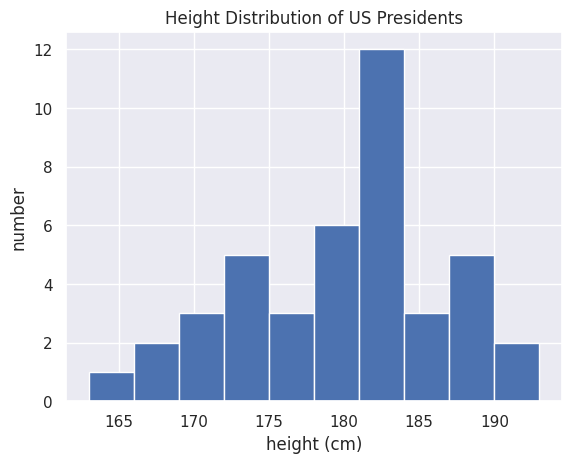

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set() # set the plot style

plt.hist(heights)
plt.title("Height Distribution of US Presidents")
plt.xlabel("height (cm)")
plt.ylabel("number");

# 5.- Computation on Arrays: Broadcasting
We saw in the previous section how NumPy's universal functions can be used to vecotrize operations and thereby remove slow Python loops. Another means of vectorizing operations is to use NumPy's broadcasting functionality. Broadcasting is simply a set of rules for applying binary ufuncs (e.g., addition, substraction, multiplication, etc.) on arrays of different sizes.

## Introduction Broadcasting
Recall that for arrays of the same size, binary operations are performed on an element-by-element basis:

In [12]:
import numpy as np
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
a + b

array([5, 6, 7])

Broadcasting allows these types of binary operations to be performed on arrays of different sizes. For example, adding a scalar to an array:

In [13]:
a + 5

array([5, 6, 7])

We can think of this as an operation that stretches or duplicates the value `5` into the array `[5, 5, 5]`, and adds the results. The advantage of NumPy's broadcaasting is that this duplication of values does not actually take place, but it is useful mental model as we think about broadcasting.

We can similarly extend this to arrays of higher dimension. Observe the result when we add a one-dimensional array to a two-dimensional array:

In [14]:
M = np.ones((3,3))
M

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [15]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

Here the one - dimensional array `a` is stretched, or broadcast accross the second dimension in order to match the shape of `M`.

While these examples are relatively easy to understand, more complicated cases can involve broadcasting of both arrays. Consider the following example:

In [16]:
a = np.arange(3)
b = np.arange(4)[:, np.newaxis]

print(a)
print(b)

[0 1 2]
[[0]
 [1]
 [2]
 [3]]


In [17]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4],
       [3, 4, 5]])

Just as before we stretched or broadcasted one value to match the shape of the other, here we've stretched both a and b to match a common shape, and the result is a two-dimensional array! The geometry of these examples is visualized in the following figure:

https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png

The light boxes represent the broadcasted values: again, this extra memory is not actually allocated in the course of the operation, but it can be useful conceptually to imagine that it is.

## Rules of Broadcasting
Broadcasting in NumPy follows a stricct set of rules to determine the interaction between the two arrays:

1. If the two arrays differ in their number of dimensions, the shape of the one wiht fewer dimensions is padded with ones on its leading (left) side.

2. If the shape of the two arrays does not match in any dimension, the array with shape equal to 1 in that dimension is stretched to match the other shape.

3. If in any dimension the sizes disagree and neither is equal to 1, an error is raised.

To make the following rules clear we will work with three different examples:

### Example 1
Adding a two=dimensional array to a one dimensional array.

In [1]:
import numpy as np

M = np.ones((2,3))
a = np.arange(3)

In [2]:
M + a 

array([[1., 2., 3.],
       [1., 2., 3.]])

### Example 2
What happens when both arrays need to be broadcasted?

In [3]:
a = np.arange(3).reshape(3,1)
b = np. arange(3)

In [4]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

### Example 3
Let's take a look at an example in which the two arrays are not compatible

In [5]:
M = np.ones((3,2))

a = np.arange(3)

In [6]:
M + a

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

Note the potential confusion here: you could imagine making `a` and `M` compatible by, say, padding `a`'s shape with ones on the right rather than the left. But this is not how the broadcasting rules work! That sort of flexibility might be useful in some cases, but it would lead to potential areas of ambiguity. If right-side padding is what you'd like, you can do this explicitly by reshaping the array.

In [7]:
a[:, np.newaxis].shape

(3, 1)

In [8]:
M + a[:, np.newaxis]

array([[1., 1.],
       [2., 2.],
       [3., 3.]])

You can also apply as an input argument of an ufunc an expression to be broadcasted.

In [9]:
np.logaddexp(M, a[:, np.newaxis])

array([[1.31326169, 1.31326169],
       [1.69314718, 1.69314718],
       [2.31326169, 2.31326169]])

## Broadcasting in Practice
Broadcasting operations form the core of many examples we'll see throughout this book. We'll now take a look at a couple simple examples of where they can be useful.

### Centering and array
We saw that ufuncs allow a NumPy user to remove the need to explicitly write slow Python loops. Broadcasting extends this ability. One commonly seen example is when centering an array of data. Imagine you have an array of 10 observations, each of which consists of 3 values. Using the standard convention, we'll store this in a 10x3 array:

In [10]:
X = np.random.random((10,3))

We can compute the mean of each feature using the `mean` aggragate across the first diemension:

In [12]:
Xmean = X.mean(0)
Xmean

array([0.6870504 , 0.45600915, 0.59723488])

And now we can center the `X` array by substracting the mean (this is a broadcasting operation)

In [14]:
X_centered = X - Xmean
X_centered

array([[-0.21060642,  0.02487894,  0.14811226],
       [ 0.19774838,  0.44872068,  0.34207972],
       [-0.06385137,  0.31317086, -0.53383095],
       [ 0.26587499, -0.39110723, -0.01769156],
       [ 0.13525772, -0.19084587, -0.05413657],
       [-0.33072207,  0.05751384,  0.01180471],
       [-0.12506781, -0.26148716,  0.04918671],
       [ 0.17221761, -0.02723915, -0.08232688],
       [ 0.26428602, -0.28971835, -0.16067919],
       [-0.30513705,  0.31611344,  0.29748174]])

To double-check that we've done this correctly, we can check that the centered array has near zero mean:

In [15]:
X_centered.mean(0)

array([-7.77156117e-17,  4.99600361e-17,  5.55111512e-17])

### Plotting a two-dimensional function
One place that broadcasting is very useful is in displaying images based on two-dimensional functions. If we want to define a function `z = f(x,y)`, broadcasting can be used to compute the function across the grid:

In [23]:
# x and y have 50 steps from 0 to 5
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)[:, np.newaxis]

z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

We'll usse Matplotlib to plot this two-dimensional array:

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt

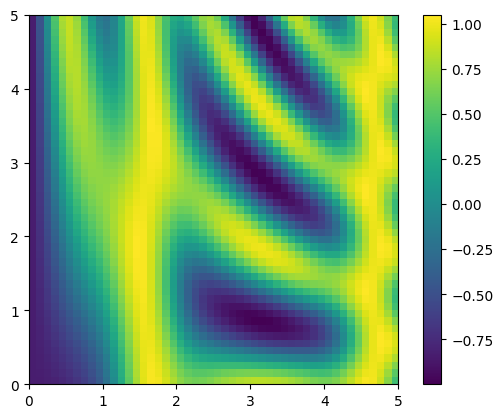

In [24]:
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5],
           cmap='viridis')
plt.colorbar();

# 6.- Comparisons, Masks, and Boolean Logic
This section covers the use of Boolean masks to examine and manipulate values within NumPy arrays. Masking comes up when you want to extract, modify, count, or otherwise manipulate values in an array based on some criterion: for example, you might wish to count all values greater than a certain value, or perhaps remove all outliers that are above some threshold. In NumPy, Boolean masking is often the most efficient way to accomplish these types of tasks.

## Example: Counting Rainy Days
Imagine you have a series of data that represents the amount of precipitation each day for a year in a given city. For example in SEattle in 2014 from the datas of the example.

In [17]:
import numpy as np
import pandas as pd

# use pandas to extract rainfall inches as a NumPy array
rainfall = pd.read_csv('data_v1/Seattle2014.csv')['PRCP']
inches = rainfall / 254.0 # 1/10 mm -> inshed
inches.shape

(365,)

The array contains 365 values, giving daily rainfall in inches from January 1 to December 31, 2014.

As a first quick visualization, let's look at the histogram of rainy days, which was generated using Matplotlib

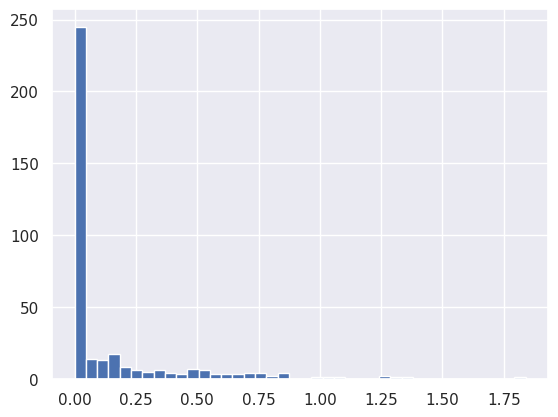

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set() 
plt.hist(inches, 40);

This histogram gives us a general idea of what the data looks like: despite its reputation, the vast majority of days in Seattle saw near zero measured rainfall in 2014. But this doesn't do a good job of conveying some information we'd like to see: for example, how many rainy days were there in the year? What is the average precipitation on those rainy days? How many days were there with more than half an inch of rain?

## Digging into the data
One approach to this would be to answer these questions by hand: loop through the data, incrementing a counter each time we see values in some desired range. For reasons discussed throughout this chapter, such an approach is very inefficient, both from the standpoint of time writing code and time computing the result. We saw in Computation on NumPy Arrays: Universal Functions that NumPy's ufuncs can be used in place of loops to do fast element-wise arithmetic operations on arrays; in the same way, we can use other ufuncs to do element-wise comparisons over arrays, and we can then manipulate the results to answer the questions we have. We'll leave the data aside for right now, and discuss some general tools in NumPy to use masking to quickly answer these types of questions.

## Comparison Operators as ufuncs
NumPy also implements comparison operators such as `<` (less than) and `>` (greater than) as element-wise ufuncs. The result of these comparison operators is always an array with a Boolean data type. All six of the standard comparison operations are available:

In [3]:
import numpy as np
x = np.array([1, 2, 3, 4, 5])

In [29]:
x < 3

array([ True,  True, False, False, False])

In [30]:
x > 3

array([False, False, False,  True,  True])

In [31]:
x <= 3

array([ True,  True,  True, False, False])

In [32]:
x >= 3

array([False, False,  True,  True,  True])

In [33]:
x!=3

array([ True,  True, False,  True,  True])

In [5]:
x == 3

array([False, False,  True, False, False])

It is also possible to do an element -wise comparison of two arrays, and to include compound expressions:

In [4]:
(x ** 2) == (x ** 2)

array([ True,  True,  True,  True,  True])

As in the case of arithmetic operators, the comparison operators are implemented as ufuncs in NumPy; for example, when you write `x < 3`, internally NumPy uses `np.less(x, 3)`. A summary of the comparison operators and their equivalent ufunc is shown here

`Operator` 	`Equivalent ufunc` 		`Operator` 	`Equivalent ufunc`

`==`	`np.equal` 		`!=` 	`np.not_equal`

`<` 	`np.less` 		`<=` 	`np.less_equal`

`>`	`np.greater` 		`>=` 	`np.greater_equal`


Just as in the case of arithmetic ufuncs, these will work on arrays of any size and shape. Here is a two-dimensional example:

In [6]:
rng = np.random.RandomState(0)
x = rng.randint(10, size=(3,4))
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [7]:
x < 6

array([[ True,  True,  True,  True],
       [False, False,  True,  True],
       [ True,  True, False, False]])

## Working with Boolean Arrays
Given a Boolean array, there are a host of useful operations you can do . We'll work with `x`, the two-dimensional array we created earlier.

In [8]:
print(x)

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]


### Counting entries
To count the number of `True` entries in a Boolean array, `np.count_nonzero(x < 6)` is useful:

In [9]:
np.count_nonzero(x < 6)

np.int64(8)

The benefit of `sum()` is that like with other NumPy agregation functions, this summation can be done along rows or columns as well:

In [10]:
np.sum(x <6, axis = 1)

array([4, 2, 2])

This counts the number of values less than 6 in each row of the matrix.

If we're interested in quickly checking whether any of all the values are true, we can use (you guessed it) `np.any` or `np.all`:

In [11]:
np.any(x > 8)

np.True_

In [12]:
np.any(x < 0)

np.False_

In [13]:
np.all(x < 10)

np.True_

In [14]:
np.all(x == 6)

np.False_

`np.all` and `np.any` can be used along particular axes as well. For example:

In [15]:
np.all(x < 8, axis=1)

array([ True, False,  True])

## Boolean operators
We've already seen how we might count, say, all days with rain less than four inches, or all days with rain greater than two inches. But what if we want to know about all days with rain less than four inches and greater than one inch? This is accomplished through Python's bitwise logic operators, &, |, ^, and ~. Like with the standard arithmetic operators, NumPy overloads these as ufuncs which work element-wise on (usually Boolean) arrays.

For example, we can address this sort of compound question as follows:

In [ ]:
import numpy as np
import pandas as pd

# use pandas to extract rainfall inches as a NumPy array
rainfall = pd.read_csv('data_v1/Seattle2014.csv')['PRCP']
inches = rainfall / 254.0 # 1/10 mm -> inshed
inches.shape

np.sum((inches > 0.5) & (inches < 1))

np.int64(29)

So we see that there are 29 days with rainfall between 0.5 and 1.0 inches.

Note that the parentheses here are important–because of operator precedence rules, with parentheses removed this expression would be evaluated as follows, which results in an error:

In [20]:
inches > (0.5 & inches) < 1

TypeError: Cannot perform 'rand_' with a dtyped [float64] array and scalar of type [bool]

Using the equivalence of A AND B and NOT (NOT A OR NOT B) (which you may remember if you've taken an introductory logic course), we can compute the same result in a different manner:

In [21]:
np.sum(~( (inches <= 0.5) | (inches >= 1) ))

np.int64(29)

Combining comparison operators and Boolean operators on arrays can lead to a wide range of efficient logical operations.

The following table summarizes the bitwise Boolean operators and their equivalent ufuncs:

Operator 	Equivalent ufunc 

`&`	`np.bitwise_and `		

`|` 	`np.bitwise_or`

`^` 	`np.bitwise_xor` 		

`~` 	`np.bitwise_not`

Using these tools, we might start to answer the types of questions we have about our weather data. Here are some examples of results we can compute when combining masking with aggregations:

In [22]:
print("Number days without rain:      ", np.sum(inches == 0))
print("Number days with rain:         ", np.sum(inches != 0))
print("Days with more than 0.5 inches:", np.sum(inches > 0.5))
print("Rainy days with < 0.2 inches  :", np.sum((inches > 0) &
                                                (inches < 0.2)))

Number days without rain:       215
Number days with rain:          150
Days with more than 0.5 inches: 37
Rainy days with < 0.2 inches  : 75


## Boolean Arrays as Masks
In the preceding section we looked at aggregates computed directly on Boolean arrays. A more powerful pattern is to use Boolean arrays as masks, to select particular subsets of the data themselves.

In [5]:
import numpy as np
rng = np.random.RandomState(0)
x = rng.randint(10, size=(3,4))
print(x)

x < 5

# Applying the mask
x[x < 5]

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]


array([0, 3, 3, 3, 2, 4])

What is returned is a one-dimensional array filled with all the values that meet this condition; in other words, all the values in positions at which the mask array is True.

We are then free to operate on these values as we wish. For example, we can compute some relevant statistics on our Seattle rain data:

In [9]:
import numpy as np
import pandas as pd

# use pandas to extract rainfall inches as a NumPy array
rainfall = pd.read_csv('data_v1/Seattle2014.csv')['PRCP']
inches = rainfall / 254.0 # 1/10 mm -> inshed
inches.shape

# construct a mask of all rainy days
rainy = (inches > 0)

# construct a mask of all summer days (June 21st is the 172nd day)
days = np.arange(365)
summer = (days > 172) & (days < 262)

print("Median precip on rainy days in 2014 (inches):   ",
      np.median(inches[rainy]))
print("Median precip on summer days in 2014 (inches):  ",
      np.median(inches[summer]))
print("Maximum precip on summer days in 2014 (inches): ",
      np.max(inches[summer]))
print("Median precip on non-summer rainy days (inches):",
      np.median(inches[rainy & ~summer]))

Median precip on rainy days in 2014 (inches):    0.19488188976377951
Median precip on summer days in 2014 (inches):   0.0
Maximum precip on summer days in 2014 (inches):  0.8503937007874016
Median precip on non-summer rainy days (inches): 0.20078740157480315


By combining Boolean operations, masking operations, and aggregates, we can very quickly answer these sorts of questions for our dataset.

## Aside: Using the Keywords and/or Versus the Operators &/|
One common point of confusion is the difference between the keywords `and` and `or` on one hand, and the operators `&` and `|` on the other hand. When would you use one versus the other?

The difference is this: `and` and `or` gauge the truth or falsehood of entire object, while `&` and `|` refer to bits within each object.

When you use `and` or `or`, it's equivalent to asking Python to treat the object as a single Boolean entity. In Python, all nonzero integers will evaluate as True. Thus:

In [10]:
bool(42), bool(0)

(True, False)

In [11]:
bool(42 and 0)

False

In [12]:
bool(42 or 0)

True

When using `&` and `|`on integers, the expression operates on the bits of the element, applying the and or the or to the individual bits making up the number.

In [13]:
bin(42)

'0b101010'

In [14]:
bin(59)

'0b111011'

In [15]:
bin(42 &59)

'0b101010'

In [17]:
bin (42 | 59)

'0b111011'

Notice that the corresponding bits of the binary representation are compared in order to yield the result.

When you have an array of Boolean values in NumPy, this can be thought of as a string of bits where 1 = True and 0 = False, and the result of & and | operates similarly to above:

In [18]:
A = np.array([1, 0, 1, 0, 1, 0], dtype=bool)
B = np.array([1, 1, 1, 0, 1, 1], dtype=bool)
A | B

array([ True,  True,  True, False,  True,  True])

Using or on these arrays will try to evaluate the truth or falsehood of the entire array object, which is not a well-defined value:

In [19]:
A or B

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Similarly, when doing a Boolean expression on a given array, you should use | or & rather than or or and:

In [20]:
x = np.arange(10)
(x > 4) & (x < 8)

array([False, False, False, False, False,  True,  True,  True, False,
       False])

Trying to evaluate the truth or falsehood of the entire array will give the same ValueError we saw previously:

In [21]:
(x > 4) and (x < 8)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

So remember this: and and or perform a single Boolean evaluation on an entire object, while & and | perform multiple Boolean evaluations on the content (the individual bits or bytes) of an object.

# 7.- Fancy Indexing
In the previous sections, we saw how to access and modify portions of arrays using simple indices (e.g., arr[0]), slices (e.g., arr[:5]), and Boolean masks (e.g., arr[arr > 0]). In this section, we'll look at another style of array indexing, known as fancy indexing. Fancy indexing is like the simple indexing we've already seen, but we pass arrays of indices in place of single scalars. This allows us to very quickly access and modify complicated subsets of an array's values.

## Exploring Fancy Indexing
Fancy indexing is conceptually simple: It means passing an array of indices to access multiple array elements at once. For example, consider the following array:

In [1]:
import numpy as np
rand = np.random.RandomState(42)

x = rand.randint(100, size = 10)
print(x)

[51 92 14 71 60 20 82 86 74 74]


If we watn three different elements we could do

In [2]:
[x[3], x[7], x[2]]

[np.int64(71), np.int64(86), np.int64(14)]

Alternatively, we can pass a single list or array of indices to obtain the same result:

In [3]:
ind = [3, 7, 4]
x[ind]

array([71, 86, 60])

When using fancy indexing, the shape of the result reflects the shape of the index arrays rather than the shape of the array being indexed:

In [25]:
ind = np.array([[3, 7], [4, 5]])

x [ind]

array([[71, 86],
       [60, 20]])

Fancy indexing also works in multiple dimensions. Consider the following array:

In [26]:
X = np.arange(12).reshape((3,4))
X

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

Like with standard indexing, the first index refers to the row, and the second to the column:

In [27]:
row = np.array([0, 1, 2])
col = np.array([2, 1, 3])

X[row, col]

array([ 2,  5, 11])

Notice that the first value in the result is X[0, 2], the second is X[1, 1], and the third is X[2, 3]. The pairing of indices in fancy indexing follows all the broadcasting rules that were mentioned in Computation on Arrays: Broadcasting. So, for example, if we combine a column vector and a row vector within the indices, we get a two-dimensional result:

In [28]:
X[row[:, np.newaxis], col]

array([[ 2,  1,  3],
       [ 6,  5,  7],
       [10,  9, 11]])

Here, each row value is matched with each column vector, exactly as we saw in broadcasting of arithmetic operations. For example:

In [29]:
row[:, np.newaxis] * col

array([[0, 0, 0],
       [2, 1, 3],
       [4, 2, 6]])

It is always important to remember with fancy indexing that the return value reflects the broadcasted shape of the indices, rather than the shape of the array being indexed.

## Combined indexing
For even more powerful operations, fancy indexing can be combined with the other indexing schemes we've seen:

In [31]:
print(X)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


We can combine fancy and simple indices:

In [32]:
X[2, [2, 0, 1]]

array([10,  8,  9])

We can also combine fancy indexing with slicing:

In [33]:
X[1:, [2, 0, 1]]

array([[ 6,  4,  5],
       [10,  8,  9]])

And we can combine fancy indexing with masking:

In [34]:
mask = np.array([1, 0, 1, 0], dtype=bool)
X[row[:, np.newaxis], mask]

array([[ 0,  2],
       [ 4,  6],
       [ 8, 10]])

All of these indexing options combined lead to a very flexible set of operations for accessing and modifying array values.

## Example: Selecting Random Points
One common use of fancy indexing is the selection of subsets of rows from a matrix. For example, we might have an N by D matrix representing N points in D dimensions, such as the following points drawn from a two-dimensional normal distribution

In [4]:
mean = [0, 0]
cov = [[1, 2], 
       [2, 5]]

X = rand.multivariate_normal(mean, cov, 100)
X.shape

(100, 2)

Using the plotting tools we will discuss in Introduction to Matplotlib, we can visualize these points as a scatter-plot:

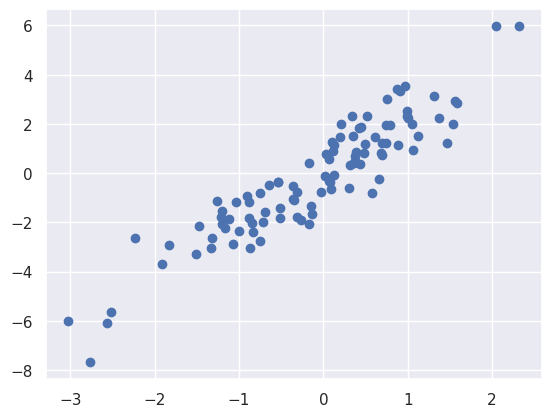

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()

plt.scatter(X[:, 0], X[:, 1]);

Let's use fancy indexing to select 20 random points. We'll do this by first choosing 20 random indices with no repeats, and use these indices to select a portion of the original array

In [6]:
indices = np.random.choice(X.shape[0], 20, replace=False)
indices

array([93, 35, 81, 91, 26, 30, 19, 46,  2, 67, 99, 12, 64,  4, 79, 55, 48,
       95, 24, 21])

In [7]:
selection = X[indices]
selection.shape

(20, 2)

Now to see which points were selected, let's over-plot large circles at the locations of the selected points:

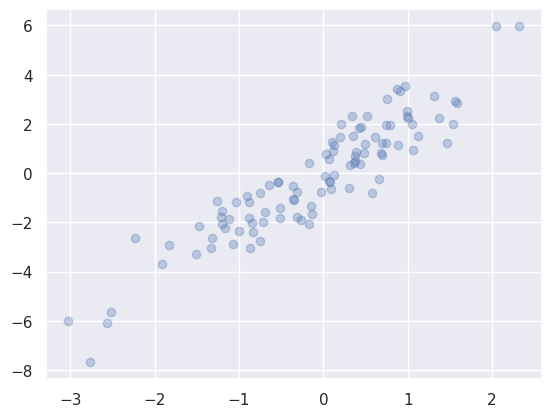

In [8]:
plt.scatter(X[:, 0], X[:,1], alpha=0.3)
plt.scatter(selection[:, 0], selection[:, 1], facecolor='none', s=200)

This sort of strategy is often used to quickly partition datasets, as is often needed in train/test splitting for validation of statistical models (see Hyperparameters and Model Validation), and in sampling approaches to answering statistical questions.

## Modifying Values with Fancy Indexing
Just as fancy indexing can be used to access parts of an array, it can also be used to modify parts of an array. For example, imagine we have an array of indeces and we'd like to set the corresponding items in an array to some value:

In [9]:
x = np.arange(10)
i = np.array([2, 1, 8, 4])
x[i] = 99
print(x)

[ 0 99 99  3 99  5  6  7 99  9]


We can use any assignment-type operator for this. For example:

In [10]:
x[i] -= 10
print(x)

[ 0 89 89  3 89  5  6  7 89  9]


Notice, though, that repeated indeces with these operations can cause some potentially unexpected results. Consider the following:

In [11]:
x = np.zeros(10)
x[[0, 0]] = [4, 6]
print(x)

[6. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Where did the 4 go? The result of this operation is to first assign x`[0] = 4`, followed by `x[0] = 6`. The result, of course, is that `x[0]` contains the value `6`.

Fair enough, but consider this operation:

In [12]:
i = [2, 3, 3, 4, 4, 4]
x[i] += 1
x

array([6., 0., 1., 1., 1., 0., 0., 0., 0., 0.])

ou might expect that x[3] would contain the value 2, and x[4] would contain the value 3, as this is how many times each index is repeated. Why is this not the case? Conceptually, this is because x[i] += 1 is meant as a shorthand of x[i] = x[i] + 1. x[i] + 1 is evaluated, and then the result is assigned to the indices in x. With this in mind, it is not the augmentation that happens multiple times, but the assignment, which leads to the rather nonintuitive results.

So what if you want the other behavior where the operation is repeated? For this, you can use the `at()` method of ufuncs (available since NumPy 1.8), and do the following:

In [13]:
x = np.zeros(10)
np.add.at(x, i, 1)
print(x)

[0. 0. 1. 2. 3. 0. 0. 0. 0. 0.]


The `at()` method does an in-place application of the given operator at the specified indices (here, i) with the specified value (here, 1). Another method that is similar in spirit is the reduceat() method of ufuncs, which you can read about in the NumPy documentation.

## Example: Binning Data
You can use these ideas to efficiently bin data to create a histogram by hand. For example, imagine we have 1,000 values and would like to quickly find where they fall within an array of bins. We could compute it using `ufunc.at` like this:

In [16]:
np.random.seed(42)
x = np.random.randn(100)

# Compute a histogram by hand
bins = np.linspace(-5, 5, 20)
counts = np.zeros_like(bins)

# find the appropriate bin for each x
i = np.searchsorted(bins, x)

# add 1 to each of these bins
np.add.at(counts, i, 1)

The counts now reflect the number of points within each bin-in other words, a histogram:

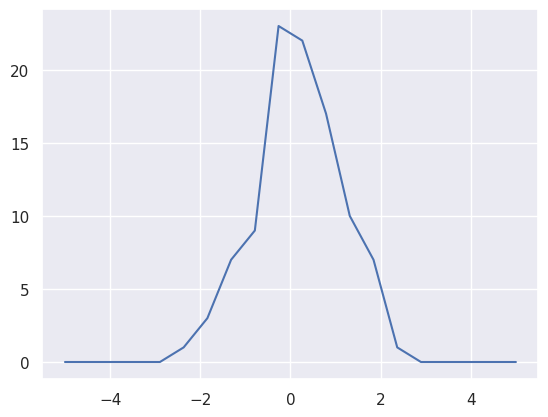

In [21]:
plt.plot(bins, counts);

Of course, it would be silly to have to do this each time you want to plot a histogram. This is why Matplotlib provides the plt.hist() routine, which does the same in a single line:

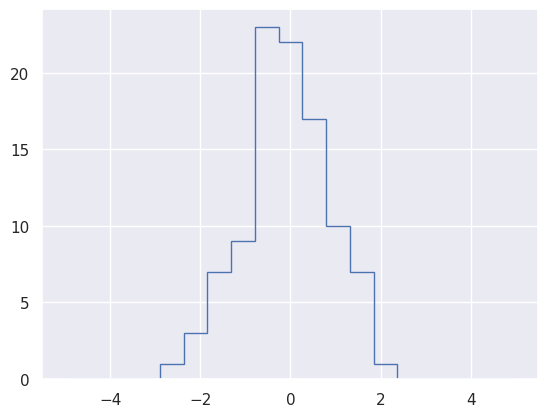

In [22]:
plt.hist(x, bins, histtype='step');

This function will create a nearly identical plot to the one seen here. To compute the binning, matplotlib uses the np.histogram function, which does a very similar computation to what we did before. Let's compare the two here:

In [23]:
print("NumPy routine: ")
%timeit counts, edges = np.histogram(x, bins)

print("Custom routine: ")
%timeit np.add.at(counts, np.searchsorted(bins, x), 1)

NumPy routine: 
5.74 μs ± 31.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Custom routine: 
4.71 μs ± 27 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Our own one-line algorithm is several times faster than the optimized algorithm in NumPy! How can this be? If you dig into the np.histogram source code (you can do this in IPython by typing np.histogram??), you'll see that it's quite a bit more involved than the simple search-and-count that we've done; this is because NumPy's algorithm is more flexible, and particularly is designed for better performance when the number of data points becomes large:

In [24]:
x = np.random.randn(1000000)
print("NumPy routine:")
%timeit counts, edges = np.histogram(x, bins)

print("Custom routine:")
%timeit np.add.at(counts, np. searchsorted(bins, x), 1)

NumPy routine:
4.73 ms ± 28 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Custom routine:
38.3 ms ± 346 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


What this comparison shows is that algorithmic efficiency is almost never a simple question. An algorithm efficient for large datasets will not always be the best choice for small datasets, and vice versa (see Big-O Notation). But the advantage of coding this algorithm yourself is that with an understanding of these basic methods, you could use these building blocks to extend this to do some very interesting custom behaviors. The key to efficiently using Python in data-intensive applications is knowing about general convenience routines like np.histogram and when they're appropriate, but also knowing how to make use of lower-level functionality when you need more pointed behavior.

# 8.- Sorting arrays
Up to this point we have been concerned mainly with tools to access and operate on array data with NumPy. This section covers algorithms related to sorting values in NumPy arrays. These algorithms are a favorite topic in introductory computer science courses: if you've ever taken one, you probably have had dreams (or, depending on your temperament, nightmares) about insertion sorts, selection sorts, merge sorts, quick sorts, bubble sorts, and many, many more. All are means of accomplishing a similar task: sorting the values in a list or array.

For example, a simple selection sort repeatedly finds the minimum value from a list, and makes swaps until the list is sorted. We can code this in just a few lines of Python:

In [26]:
import numpy as np

def selection_sort(x):
    for i in range(len(x)):
        swap = i + np.argmin(x[i:])
        (x[i], x[swap]) = (x[swap], x[i])
    return x


In [27]:
x = np.array([2, 1, 4, 3, 5])
selection_sort(x)

array([1, 2, 3, 4, 5])

As any first-year computer science major will tell you, the selection sort is useful for its simplicity, but is much too slow to be useful for larger arrays. For a list of N values, it requires N loops, each of which does on order ∼N comparisons to find the swap value. In terms of the "big-O" notation often used to characterize these algorithms (see Big-O Notation), selection sort averages O[N2]: if you double the number of items in the list, the execution time will go up by about a factor of four.

Even selection sort, though, is much better than my all-time favorite sorting algorithms, the bogosort:

In [29]:
def bogosort(x):
    while np.any(x[:-1] > x[1:]):        np.random.shuffle(x)
    return x

In [30]:
x = np.array([2, 1, 4, 3, 5])
bogosort(x)

array([1, 2, 3, 4, 5])

This silly sorting method relies on pure chance: it repeatedly applies a random shuffling of the array until the result happens to be sorted. With an average scaling of O[N×N!], (that's N times N factorial) this should–quite obviously–never be used for any real computation.

Fortunately, Python contains built-in sorting algorithms that are much more efficient than either of the simplistic algorithms just shown. We'll start by looking at the Python built-ins, and then take a look at the routines included in NumPy and optimized for NumPy arrays.

## Fast sorting in NumPy: `np.sort` and `np.argsort`
Although Python has built-in sort and sorted functions to work with lists, we won't discuss them here because NumPy's np.sort function turns out to be much more efficient and useful for our purposes. By default `np.sort` uses an `O[NlogN]`, quicksort algorithm, though mergesort and heapsort are also available. For most applications, the default quicksort is more than sufficient.

To return a sorted version of the array without modifying the input, you can use `np.sort`:


In [2]:
import numpy as np
x = np.array([2, 1, 4, 3, 5])
np.sort(x)

array([1, 2, 3, 4, 5])

If you prefer to sort the array in=place, you can instead use the `sort` method of arrays:

In [3]:
x.sort()
print(x)

[1 2 3 4 5]


A related function is argsort, which instead returns the indices of the sorted elements:

In [4]:
x = np.array([2, 1, 4, 3, 5])
i = np.argsort(x)
print(i)

[1 0 3 2 4]


The first element of this result gives the index of the smallest element, the second value gives the index of the second smallest, and so on. These indices can then be used (via fancy indexing) to construct the sorted array if desired:

In [5]:
x[i]

array([1, 2, 3, 4, 5])

### Sorting along rows or columns
A useful feature of NumPy's sorting algorithms is the ability to sort along specific rows or columns of a multidimensional array using the `axis` argument. For exmaple:

In [6]:
rand = np.random.RandomState(42)
X = rand.randint(0, 10, (4, 6))
print(X)

[[6 3 7 4 6 9]
 [2 6 7 4 3 7]
 [7 2 5 4 1 7]
 [5 1 4 0 9 5]]


In [8]:
# sort each column of X
np.sort(X, axis=0)

array([[2, 1, 4, 0, 1, 5],
       [5, 2, 5, 4, 3, 7],
       [6, 3, 7, 4, 6, 7],
       [7, 6, 7, 4, 9, 9]])

In [9]:
np.sort(X, axis=1)

array([[3, 4, 6, 6, 7, 9],
       [2, 3, 4, 6, 7, 7],
       [1, 2, 4, 5, 7, 7],
       [0, 1, 4, 5, 5, 9]])

Keep in mind that this treats each row or column as an independent array, and any relationships between the row or column values will be lost!

## Partial Sorts: Partitioning
Sometimes we're not interested in sorting the entire array, but simply want to find the k smallest values in the array. NumPy provides this in the `np.partition` function. `np.partition` takes an array and a number K; the result is a new array with the smallest K values to the left of the partition, and the remaining values to the right, in arbitrary order:

In [11]:
x = np.array([7, 2, 3, 1, 6, 5, 4])
np.partition(x, 3)

array([1, 2, 3, 4, 5, 6, 7])

Note that the first three values in the resulting array are the three smallest in the array, and the remaining array positions contain the remaining values. Within the two partitions, the elements have arbitrary order.

Similarly to sorting, we can partition along an arbitrary axis of a multidimensional array:

In [12]:
np.partition(X, 2, axis=1)

array([[3, 4, 6, 6, 7, 9],
       [2, 3, 4, 6, 7, 7],
       [1, 2, 4, 5, 7, 7],
       [0, 1, 4, 5, 5, 9]])

The result is an array where the first two slots in each row contain the smallest values from that row, with the remaining values filling the remaining slots.

Finally, just as there is a np.argsort that computes indices of the sort, there is a `np.argpartition` that computes indices of the partition. We'll see this in action in the following section.

## Example: k-Nearest Neighbors
Let's quickly see how we might use this `argsort` function along multiple axes to find the nearest neighbors of each point in a set. We'll start by creating a random set of 10 points on a two-dimensional plane. Using the standard convention, we'll arrange these in a 10×2 array:

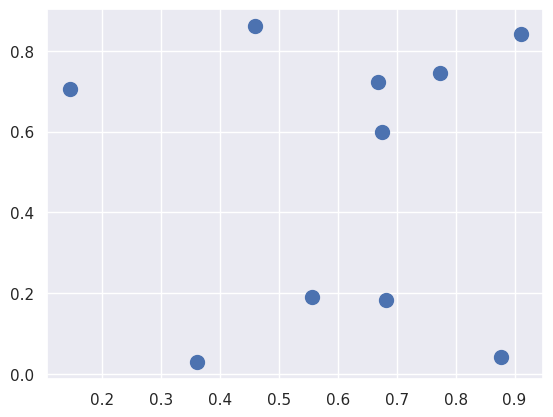

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn; seaborn.set()

rand = np.random
X = rand.rand(10,2)

plt.scatter(X[:,0], X[:, 1], s = 100)


Now, we'll compute the distance between each pait of points. Recall that the squared-distance between two points is the sum of the squared differences in each dimension; using the efficient broadcasting and aggregation routines provided by NumPy we can compute the matrix of square distances in a single line of code:

In [9]:
dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis = -1)
print(dist_sq)

[[0.         0.5596694  0.27301817 0.39628656 0.50481773 0.97825636
  0.29044265 0.43550074 0.12221379 0.60341042]
 [0.5596694  0.         0.29138027 0.32430809 0.12674056 0.05895746
  0.17324752 0.0156292  0.50867066 0.48696463]
 [0.27301817 0.29138027 0.         0.01174061 0.57669635 0.5100936
  0.01528101 0.29744648 0.06274587 0.07305625]
 [0.39628656 0.32430809 0.01174061 0.         0.68450393 0.50780114
  0.03121414 0.35660375 0.11267694 0.02806147]
 [0.50481773 0.12674056 0.57669635 0.68450393 0.         0.26708556
  0.42426258 0.06409177 0.7027188  0.96472386]
 [0.97825636 0.05895746 0.5100936  0.50780114 0.26708556 0.
  0.35419864 0.12522116 0.84889379 0.64481966]
 [0.29044265 0.17324752 0.01528101 0.03121414 0.42426258 0.35419864
  0.         0.18227299 0.1146766  0.11487349]
 [0.43550074 0.0156292  0.29744648 0.35660375 0.06409177 0.12522116
  0.18227299 0.         0.46093381 0.55220085]
 [0.12221379 0.50867066 0.06274587 0.11267694 0.7027188  0.84889379
  0.1146766  0.460933

This operatio has a lot packed into it, and it might be a bit confusing if you're unfamiliar with NumPy's broadcasting rules. When you come across code like this, it can be useful to break it down into its components steps:

In [11]:
# for each pair of points, compute differences in their coordinates
differences = X[:, np.newaxis, :] - X[np.newaxis, :, :]
differences.shape

(10, 10, 2)

In [12]:
# Square the coordinate differences
sq_differences = differences ** 2
sq_differences.shape

(10, 10, 2)

In [13]:
# Sum the coordinate differences to get the squared distance
dist_sq = sq_differences.sum(-1)
dist_sq.shape

(10, 10)

Just to double-check what we are doing, we should see that the diagonal of this matrix (i.e., the set of distances between each point and itself) is all zero:

In [14]:
dist_sq.diagonal()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

It checks out! With the pairwise square-distances converted, we can now use np.argsort to sort along each row. The leftmost columns will then give the indices of the nearest neighbors:

In [15]:
nearest = np.argsort(dist_sq, axis =1)
print(nearest)

[[0 8 2 6 3 7 4 1 9 5]
 [1 7 5 4 6 2 3 9 8 0]
 [2 3 6 8 9 0 1 7 5 4]
 [3 2 9 6 8 1 7 0 5 4]
 [4 7 1 5 6 0 2 3 8 9]
 [5 1 7 4 6 3 2 9 8 0]
 [6 2 3 8 9 1 7 0 5 4]
 [7 1 4 5 6 2 3 0 8 9]
 [8 2 3 6 0 9 7 1 4 5]
 [9 3 2 6 8 1 7 0 5 4]]


Notice that the first column gives the numbers 0 through 9 in order: this is due to the fact that each point's closest neighbor is itself, as we would expect.

By using a full sort here, we've actually done more work than we need to in this case. If we're simply interested in the nearest k neighbors, all we need is to partition each row so that the smallest `k+1` squared distances come first, with larger distances filling the remaining positions of the array. We can do this with the `np.argpartition` function:

In [16]:
K = 2
nearest_partition = np.argpartition(dist_sq, K+1, axis=1)

In order to visualize this network of neighbors, let's quickly plot the points along with lines representing the connections from each point to its two nearest neighbors:

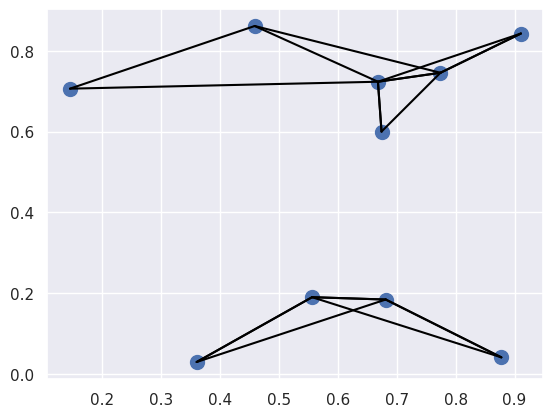

In [17]:
plt.scatter(X[:, 0], X[:, 1], s=100)

K = 2

for i in range(X.shape[0]):
    for j in nearest_partition[i, :K+1]:
        plt.plot(*zip(X[j], X[i]), color='black')

Each point in the plot has lines drawn to its two nearest neighbors. At first glance, it might seem strange that some of the points have more than two lines coming out of them: this is due to the fact that if point A is one of the two nearest neighbors of point B, this does not necessarily imply that point B is one of the two nearest neighbors of point A.

Although the broadcasting and row-wise sorting of this approach might seem less straightforward than writing a loop, it turns out to be a very efficient way of operating on this data in Python. You might be tempted to do the same type of operation by manually looping through the data and sorting each set of neighbors individually, but this would almost certainly lead to a slower algorithm than the vectorized version we used. The beauty of this approach is that it's written in a way that's agnostic to the size of the input data: we could just as easily compute the neighbors among 100 or 1,000,000 points in any number of dimensions, and the code would look the same.

Finally, I'll note that when doing very large nearest neighbor searches, there are tree-based and/or approximate algorithms that can scale as O[NlogN] or better rather than the O[N2] of the brute-force algorithm.

# 9.- Structured Data: Numpy's Structured Arrays
While often our data can be well represented by a homogeneous array of values, sometimes this is not the case. This section demonstrates the use of NumPy's structured arrays and record arrays, which provide efficient storage for compound, heterogeneous data. While the patterns shown here are useful for simple operations, scenarios like this often lend themselves to the use of Pandas Dataframes.

In [18]:
import numpy as np

Imagine that we have several categories of data on a number of people (say, name, age, and wight), and we'd like to store these values for use in a Python program. It would be possible to store these in three separete arrays:

In [19]:
name = ['Alice', 'Bob', 'Cathy', 'Doug']
age = [ 25, 45, 37, 19]
weight = [55.0, 85.5, 68.0, 61.5]

But this is a bit clumsy. There's nothing here that tells us that the three arrays are related; it would be more natural if we could use a single structure to store all of this data. NumPy can handle this through structured arrays, which are arrays with compound data types.

Recall that previously we created a simple array using an expression like this:

In [20]:
x = np.zeros(4, dtype=int)

We can similarly create a structured array using a compound data type specification:

In [22]:
data = np.zeros(4, dtype={'names':('name', 'age', 'weight'), 'formats':('U10', 'i4', 'f8')})
print(data.dtype)

[('name', '<U10'), ('age', '<i4'), ('weight', '<f8')]


Here 'U10' translates to "Unicode string of maximum length 10," 'i4' translates to "4-byte (i.e., 32 bit) integer," and 'f8' translates to "8-byte (i.e., 64 bit) float." We'll discuss other options for these type codes in the following section.

Now that we've created an empty container array, we can fill the array with our lists of values:

In [23]:
data['name'] = name
data['age'] = age
data['weight'] = weight
print(data)

[('Alice', 25, 55. ) ('Bob', 45, 85.5) ('Cathy', 37, 68. )
 ('Doug', 19, 61.5)]


As we had hoped, the data is now arranged together in one convenient block of memory.

The handy thing with structured arrays is that you can now refer to values either by index or by name:

In [24]:
data['name']

array(['Alice', 'Bob', 'Cathy', 'Doug'], dtype='<U10')

In [25]:
data[0]

np.void(('Alice', 25, 55.0), dtype=[('name', '<U10'), ('age', '<i4'), ('weight', '<f8')])

In [26]:
data[-1]['name']

np.str_('Doug')

Using Boolean masking, this even allows you to do some more sophisticated operations such as filtering on age:

In [27]:
data[data['age'] < 30]['name']

array(['Alice', 'Doug'], dtype='<U10')

Note that if you'd like to do any operations that are any more complicated than these, you should probably consider the Pandas package.

## Creating Structured Arrays
structured array data types can be specified in a number of ways. Earlier, we saw the dictionary method:

In [29]:
np.dtype({'names':('name', 'age', 'weight'),
          'formats':('U10', 'i4', 'f8')})

dtype([('name', '<U10'), ('age', '<i4'), ('weight', '<f8')])

For clarity, numerical types can be specified using Python types or NumPy dtypes instead:

In [30]:
np.dtype({'names':('name', 'age', 'weight'),
          'formats':((np.str_, 10), int, np.float32)})

dtype([('name', '<U10'), ('age', '<i8'), ('weight', '<f4')])

A compound type can also be specified as a list of tuples:

In [31]:
np.dtype([('name', 'S10'), ('age', 'i4'), ('weight', 'f8')])

dtype([('name', 'S10'), ('age', '<i4'), ('weight', '<f8')])

If the names of the types do not matter to you, you can specify the types alone in a comma-separated string:

In [32]:
np.dtype('S10,i4,f8')

dtype([('f0', 'S10'), ('f1', '<i4'), ('f2', '<f8')])

The shortened string format codes may seem confusing, but they are built on simple principles. The first (optional) character is < or >, which means "little endian" or "big endian," respectively, and specifies the ordering convention for significant bits. The next character specifies the type of data: characters, bytes, ints, floating points, and so on (see the table below). The last character or characters represents the size of the object in bytes.

**Character** 	**Description** 	**Example**

`'b'` 	`Byte` 	`np.dtype('b')`

`'i'` 	`Signed integer` 	`np.dtype('i4') == np.int32`

`'u'` 	`Unsigned integer` 	`np.dtype('u1') == np.uint8`

`'f'` 	`Floating point `	`np.dtype('f8') == np.int64`

`'c'` 	`Complex floating point` 	`np.dtype('c16') == np.complex128`

`'S', 'a'` 	`String` 	`np.dtype('S5')`

`'U'` 	`Unicode string` 	`np.dtype('U') == np.str_`

`'V'` 	`Raw data (void)` 	`np.dtype('V') == np.void`

## More Advanced Compound Types
It is possible to define even more advanced compound types. For example, you can create a type where each element contains an array or matrix of values. Here, we'll create a data type with a `mat` component consisting of a 3×3 floating-point matrix:

In [33]:
tp = np.dtype([('id', 'i8'), ('mat', 'f8', (3,3))])
X = np.zeros(1, dtype=tp)
print(X[0])
print(X['mat'][0])

(0, [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


Now each element in the `X` array consists of an `id` and a 3×3 matrix. Why would you use this rather than a simple multidimensional array, or perhaps a Python dictionary? The reason is that this NumPy dtype directly maps onto a C structure definition, so the buffer containing the array content can be accessed directly within an appropriately written C program. If you find yourself writing a Python interface to a legacy C or Fortran library that manipulates structured data, you'll probably find structured arrays quite useful!

## Record Arrays: Structured Arrays with a Twist
NumPy also provides the `np.recarray` class, which is almost identical to the structured arrays just described, but with one additional feature: fields can be accessed as attributes rather than a dictionary keys.


In [34]:
data['age']

array([25, 45, 37, 19], dtype=int32)

If we view our data as a record array instead, we can access this with slightly fewer keystrokes:

In [35]:
data_rec = data.view(np.recarray)
data_rec.age

array([25, 45, 37, 19], dtype=int32)

The downside is that for record arrays, there is some extra overhead involved in accessing the fields, even when using the same syntax. We can see this here:

In [36]:
%timeit data['age']
%timeit data_rec['age']
%timeit data_rec.age

35.6 ns ± 0.238 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
507 ns ± 2.31 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
1.02 μs ± 2.75 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Whether the more convenient notation is worth the additional overhead will depend on your own application.
